# Phase 3: PaddleOCR Integration
## Smart Document Extraction Pipeline

**Kaggle Notebook** | CPU or GPU | ~1 hour runtime

---

### Before Running
1. **Add Phase 2 Dataset**: Add Data -> Your Datasets -> `sdep-phase-2-output` -> Add
2. **Add SROIE Dataset**: Add Data -> `SROIE datasetv2` by urbikn -> Add
3. **Internet**: ON
4. **Accelerator**: T4 GPU (optional -- PaddleOCR runs on CPU but YOLO is faster on GPU)

---

### What This Notebook Does

| Cell | Task | Output |
|------|------|--------|
| 1-3 | Install, imports, paths | Environment ready |
| 4-5 | Load YOLO26 + test region detection | Verified detector |
| 6-7 | Install PaddleOCR + smoke test | Verified OCR |
| 8 | Write `ocr_engine.py` wrapper | Reusable OCR module |
| 9-11 | Full pipeline: YOLO -> crop -> OCR | Text + word bboxes per region |
| 12 | Batch test on 10 receipts + latency | Per-stage timing |
| 13-15 | Save all results for Phase 4 | Complete Phase 3 output |

In [1]:
# Install tesseract as system binary -- zero Python dependency conflicts
!apt-get install -y tesseract-ocr -q
!pip install pytesseract -q

import pytesseract
print(f'Tesseract: {pytesseract.get_tesseract_version()}')

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 141 not upgraded.
Tesseract: 4.1.1


In [2]:
# Cell 2: Install dependencies
!pip install ultralytics>=8.3.0 opencv-python Pillow pandas matplotlib tqdm pydantic -q
!pip install pytesseract -q
print('All dependencies installed')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [3]:
# Cell 3: Imports and GPU check
import os, json, shutil, time, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from PIL import Image, ImageDraw
from tqdm import tqdm
import torch

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

n_gpus = torch.cuda.device_count()
DEVICE = '0' if n_gpus > 0 else 'cpu'
print(f'GPU count: {n_gpus} | YOLO device: {DEVICE}')
print(f'PaddleOCR device: CPU (always)')

GPU count: 2 | YOLO device: 0
PaddleOCR device: CPU (always)


In [4]:
# Cell 4: Path setup -- load Phase 2 assets

PHASE2_DIR  = Path('/kaggle/input/datasets/daudshah/sdep-phase-2-output/doc-extraction-pipeline')
SROIE_ROOT  = Path('/kaggle/input/datasets/urbikn/sroie-datasetv2')  # corrected path
WORKING_DIR = Path('/kaggle/working/doc-extraction-pipeline')
RESULTS_DIR = WORKING_DIR / 'results'
OUTPUTS_DIR = WORKING_DIR / 'outputs/annotated'
SRC_DIR     = WORKING_DIR / 'src'

for d in [RESULTS_DIR, OUTPUTS_DIR, SRC_DIR, WORKING_DIR / 'data/sroie']:
    d.mkdir(parents=True, exist_ok=True)

# Copy Phase 2 src files forward
p2_src = PHASE2_DIR / 'src'
if p2_src.exists():
    for f in p2_src.iterdir():
        shutil.copy2(f, SRC_DIR / f.name)
    print(f'Copied Phase 2 src: {[f.name for f in p2_src.iterdir()]}')

# Copy Phase 2 results forward
p2_results = PHASE2_DIR / 'results'
if p2_results.exists():
    for f in p2_results.iterdir():
        shutil.copy2(f, RESULTS_DIR / f.name)
    print(f'Copied Phase 2 results: {[f.name for f in p2_results.iterdir()]}')

# Load SROIE index
sroie_df   = None
test_paths = []   # always initialise first -- avoids NameError

for candidate in [
    PHASE2_DIR / 'data/sroie/sroie_index.csv',
    PHASE2_DIR.parent / 'data/sroie/sroie_index.csv',
]:
    if candidate.exists():
        sroie_df = pd.read_csv(candidate)
        print(f'SROIE index loaded: {len(sroie_df)} receipts')
        break

if sroie_df is None:
    print('SROIE index not found -- loading receipts directly from SROIE input')

# Collect test receipt image paths
if sroie_df is not None:
    candidates = sroie_df[sroie_df['split'] == 'test']['image_path'].tolist()
    test_paths = [p for p in candidates if Path(p).exists()]

# Fallback: scan SROIE dataset input directly
if not test_paths:
    if SROIE_ROOT.exists():
        test_paths = sorted(SROIE_ROOT.rglob('*.jpg'))[:50]
        print(f'Using SROIE input directly: {len(test_paths)} images found')
    else:
        print(f'WARNING: SROIE not found at {SROIE_ROOT}')
        print('Make sure SROIE datasetv2 is added via Add Data')

print(f'Test receipts available: {len(test_paths)}')
if test_paths:
    print(f'  First: {test_paths[0]}')

# Phase 2 model checkpoint
YOLO_PT = PHASE2_DIR / 'models/yolo26_doclaynet/yolo26_doclaynet_best.pt'
print(f'\nYOLO checkpoint: {YOLO_PT}')
print(f'  Exists: {YOLO_PT.exists()}')

Copied Phase 2 src: ['schema.py']
Copied Phase 2 results: ['phase2_summary.md', 'phase2_results.json']
SROIE index not found -- loading receipts directly from SROIE input
Using SROIE input directly: 50 images found
Test receipts available: 50
  First: /kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/img/X00016469670.jpg

YOLO checkpoint: /kaggle/input/datasets/daudshah/sdep-phase-2-output/doc-extraction-pipeline/models/yolo26_doclaynet/yolo26_doclaynet_best.pt
  Exists: True


In [5]:
# Cell 5: Load YOLO26 and verify on one receipt
from ultralytics import YOLO

YOLO_CLASSES = ['Text', 'Table', 'Section-header', 'Title', 'Picture']

yolo_model = YOLO(str(YOLO_PT))
print(f'YOLO26 loaded: {YOLO_PT.name}')

# Quick test on first receipt
sample_img_path = test_paths[0]
sample_img      = Image.open(sample_img_path).convert('RGB')

t0     = time.time()
result = yolo_model.predict(
    source  = str(sample_img_path),
    imgsz   = 640,
    conf    = 0.25,
    iou     = 0.45,
    device  = DEVICE,
    verbose = False,
)[0]
yolo_ms = (time.time() - t0) * 1000

n_boxes = len(result.boxes) if result.boxes is not None else 0
print(f'Sample receipt: {Path(sample_img_path).name}')
print(f'  Image size:      {sample_img.size}')
print(f'  Regions found:   {n_boxes}')
print(f'  YOLO latency:    {yolo_ms:.0f} ms')

if result.boxes is not None and n_boxes > 0:
    cls_ids = result.boxes.cls.cpu().numpy().astype(int)
    confs   = result.boxes.conf.cpu().numpy()
    print(f'  Detected regions:')
    for cls_id, conf in zip(cls_ids, confs):
        cls_name = YOLO_CLASSES[cls_id] if cls_id < len(YOLO_CLASSES) else str(cls_id)
        print(f'    {cls_name:<18} conf={conf:.3f}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO26 loaded: yolo26_doclaynet_best.pt
Sample receipt: X00016469670.jpg
  Image size:      (463, 894)
  Regions found:   7
  YOLO latency:    1842 ms
  Detected regions:
    Section-header     conf=0.732
    Section-header     conf=0.672
    Text               conf=0.539
    Section-header     conf=0.505
    Section-header     conf=0.423
    Section-header     conf=0.385
    Text               conf=0.382


In [6]:
# Cell 6: Initialize pytesseract and smoke test
import pytesseract
from pytesseract import Output

# Verify tesseract is available
print(f'Tesseract version: {pytesseract.get_tesseract_version()}')

def ocr_to_words(img_pil, psm=6):
    """
    Run pytesseract on a PIL image.
    Returns list of dicts: {text, confidence, quad_bbox, xyxy_bbox}
    psm=6: assume uniform block of text (best for receipt regions)
    psm=11: sparse text (best for full receipt page)
    """
    data = pytesseract.image_to_data(
        img_pil,
        output_type  = Output.DICT,
        config       = f'--psm {psm} --oem 3',
    )
    words = []
    for i in range(len(data['text'])):
        text = data['text'][i].strip()
        conf = int(data['conf'][i])
        if not text or conf < 0:
            continue
        x1 = data['left'][i]
        y1 = data['top'][i]
        x2 = x1 + data['width'][i]
        y2 = y1 + data['height'][i]
        words.append({
            'text':       text,
            'confidence': round(conf / 100.0, 4),
            'quad_bbox':  [[x1,y1],[x2,y1],[x2,y2],[x1,y2]],
            'xyxy_bbox':  [x1, y1, x2, y2],
        })
    return words

# Smoke test on full receipt
t0     = time.time()
words  = ocr_to_words(sample_img, psm=11)
ocr_ms = (time.time() - t0) * 1000

print(f'\nPytesseract smoke test:')
print(f'  Latency:     {ocr_ms:.0f} ms')
print(f'  Words found: {len(words)}')
print(f'\nFirst 5 words:')
for w in words[:5]:
    print(f'  {w["text"]:<28} conf={w["confidence"]:.3f}')

Tesseract version: 4.1.1

Pytesseract smoke test:
  Latency:     791 ms
  Words found: 109

First 5 words:
  tan                          conf=0.930
  chay                         conf=0.920
  yee                          conf=0.960
  ***                          conf=0.870
  COPY                         conf=0.910


In [7]:
# Cell 7: Test pytesseract on a YOLO-cropped region

if result.boxes is not None and len(result.boxes) > 0:
    box      = result.boxes.xyxy[0].cpu().numpy().astype(int)
    cls_id   = int(result.boxes.cls[0].item())
    cls_name = YOLO_CLASSES[cls_id] if cls_id < len(YOLO_CLASSES) else str(cls_id)

    x1, y1, x2, y2 = box
    crop = sample_img.crop((x1, y1, x2, y2))

    print(f'Cropped region: {cls_name} | size: {crop.size}')

    t0         = time.time()
    crop_words = ocr_to_words(crop, psm=6)
    crop_ms    = (time.time() - t0) * 1000

    print(f'OCR on cropped region:')
    print(f'  Latency:     {crop_ms:.0f} ms')
    print(f'  Words found: {len(crop_words)}')
    for w in crop_words[:8]:
        print(f'  {w["text"]:<30} conf={w["confidence"]:.3f}')

Cropped region: Section-header | size: (116, 18)
OCR on cropped region:
  Latency:     121 ms
  Words found: 2
  TAX                            conf=0.960
  INVOICE                        conf=0.950


In [8]:
# Cell 8: Write src/ocr_engine.py -- pytesseract backend

OCR_ENGINE_CODE = '''
"""
ocr_engine.py -- Phase 3
Pytesseract wrapper for the Smart Document Extraction Pipeline.
No dependency conflicts. Works on CPU. HF Space compatible.
Requires: apt-get install tesseract-ocr
"""
import numpy as np
from PIL import Image
import pytesseract
from pytesseract import Output


def _run_tesseract(img_pil, psm=6):
    data = pytesseract.image_to_data(
        img_pil,
        output_type = Output.DICT,
        config      = f"--psm {psm} --oem 3",
    )
    words = []
    for i in range(len(data["text"])):
        text = data["text"][i].strip()
        conf = int(data["conf"][i])
        if not text or conf < 0:
            continue
        x1 = data["left"][i]
        y1 = data["top"][i]
        x2 = x1 + data["width"][i]
        y2 = y1 + data["height"][i]
        words.append({
            "text":       text,
            "confidence": round(conf / 100.0, 4),
            "quad_bbox":  [[x1,y1],[x2,y1],[x2,y2],[x1,y2]],
            "xyxy_bbox":  [x1, y1, x2, y2],
        })
    return words


class OCREngine:
    def __init__(self, lang="en", use_gpu=False):
        # lang and use_gpu kept for API compatibility -- tesseract is always CPU
        self._lang = lang

    def run_on_image(self, image):
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)
        return _run_tesseract(image, psm=11)

    def run_on_region(self, full_image, region_xyxy):
        x1, y1, x2, y2 = [int(v) for v in region_xyxy]
        crop  = full_image.crop((x1, y1, x2, y2))
        words = _run_tesseract(crop, psm=6)
        # Shift bboxes from crop coords to full image coords
        for w in words:
            w["quad_bbox"] = [[p[0]+x1, p[1]+y1] for p in w["quad_bbox"]]
            bx1,by1,bx2,by2 = w["xyxy_bbox"]
            w["xyxy_bbox"] = [bx1+x1, by1+y1, bx2+x1, by2+y1]
        return words

    def run_pipeline(self, full_image, yolo_result, yolo_classes):
        output = {}
        if yolo_result.boxes is None or len(yolo_result.boxes) == 0:
            return output
        boxes   = yolo_result.boxes.xyxy.cpu().numpy()
        cls_ids = yolo_result.boxes.cls.cpu().numpy().astype(int)
        confs   = yolo_result.boxes.conf.cpu().numpy()
        for idx, (box, cls_id, conf) in enumerate(zip(boxes, cls_ids, confs)):
            cls_name = yolo_classes[cls_id] if cls_id < len(yolo_classes) else str(cls_id)
            words    = self.run_on_region(full_image, box)
            output[idx] = {
                "region_class": cls_name,
                "region_bbox":  [float(v) for v in box],
                "confidence":   round(float(conf), 4),
                "words":        words,
            }
        return output
'''

engine_path = SRC_DIR / 'ocr_engine.py'
engine_path.write_text(OCR_ENGINE_CODE.strip(), encoding='utf-8')
print(f'ocr_engine.py written ({engine_path.stat().st_size} bytes)')

import importlib.util
spec = importlib.util.spec_from_file_location('ocr_engine', engine_path)
ocr_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ocr_mod)

engine = ocr_mod.OCREngine(lang='en', use_gpu=False)
print('OCREngine instantiated successfully')

ocr_engine.py written (2699 bytes)
OCREngine instantiated successfully


In [9]:
# Cell 9: Full pipeline on one receipt -- YOLO -> crop -> OCR
# This is the exact Path A flow used in production

sample_img = Image.open(test_paths[0]).convert('RGB')

# Stage 1: YOLO layout detection
t_yolo = time.time()
yolo_out = yolo_model.predict(
    source  = str(test_paths[0]),
    imgsz   = 640,
    conf    = 0.25,
    iou     = 0.45,
    device  = DEVICE,
    verbose = False,
)[0]
yolo_ms = (time.time() - t_yolo) * 1000

# Stage 2: OCR on each detected region
t_ocr    = time.time()
pipeline_output = engine.run_pipeline(sample_img, yolo_out, YOLO_CLASSES)
ocr_ms   = (time.time() - t_ocr) * 1000

total_ms = yolo_ms + ocr_ms

# Print results
print(f'Pipeline Results -- {Path(test_paths[0]).name}')
print(f'  YOLO detection:  {yolo_ms:.0f} ms | {len(pipeline_output)} regions')
print(f'  OCR all regions: {ocr_ms:.0f} ms')
print(f'  Total pipeline:  {total_ms:.0f} ms')
print()

total_words = 0
for idx, region in pipeline_output.items():
    n_words = len(region['words'])
    total_words += n_words
    print(f'  Region {idx}: {region["region_class"]:<18} '
          f'conf={region["confidence"]:.2f} | {n_words} words')
    for w in region['words'][:3]:
        print(f'    "{w["text"]}"  conf={w["confidence"]:.3f}')
    if n_words > 3:
        print(f'    ... ({n_words-3} more words)')

print(f'\nTotal words extracted: {total_words}')

Pipeline Results -- X00016469670.jpg
  YOLO detection:  21 ms | 7 regions
  OCR all regions: 1143 ms
  Total pipeline:  1164 ms

  Region 0: Section-header     conf=0.73 | 2 words
    "TAX"  conf=0.960
    "INVOICE"  conf=0.950
  Region 1: Section-header     conf=0.67 | 3 words
    "tan"  conf=0.930
    "chay"  conf=0.920
    "yee"  conf=0.960
  Region 2: Text               conf=0.54 | 13 words
    "Goods"  conf=0.920
    "Sold"  conf=0.960
    "Are"  conf=0.960
    ... (10 more words)
  Region 3: Section-header     conf=0.50 | 5 words
    "KINGS"  conf=0.950
    "SAFETY"  conf=0.940
    "SHOES"  conf=0.930
    ... (2 more words)
  Region 4: Section-header     conf=0.42 | 1 words
    "Address"  conf=0.950
  Region 5: Section-header     conf=0.38 | 9 words
    "ee"  conf=0.240
    "COPre"  conf=0.000
    "O3JC"  conf=0.350
    ... (6 more words)
  Region 6: Text               conf=0.38 | 23 words
    "‘Invoice"  conf=0.840
    "No:"  conf=0.680
    "PEGIV-1030765."  conf=0.000
    ... (

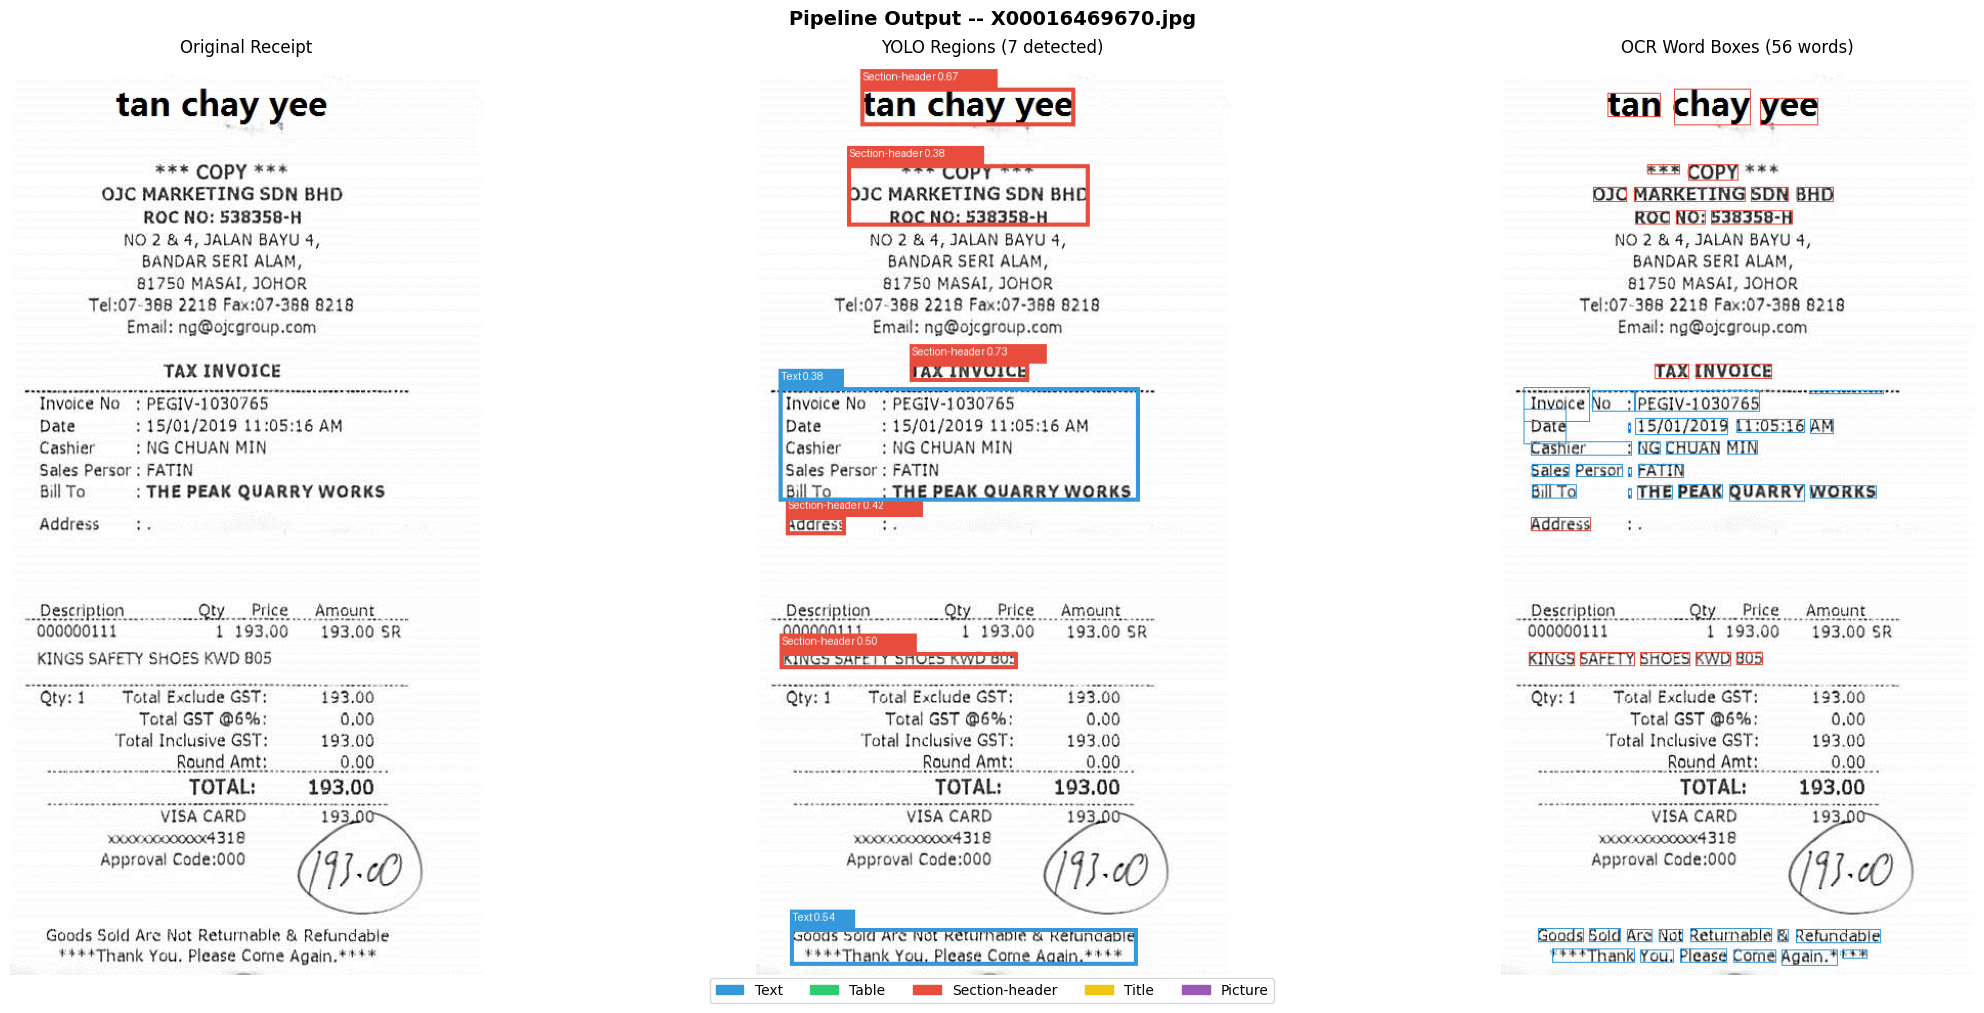

Saved -> /kaggle/working/doc-extraction-pipeline/outputs/annotated/phase3_pipeline_single.png


In [10]:
# Cell 10: Visualize pipeline output on one receipt
# Shows YOLO boxes + OCR word boxes on the same image

REGION_COLORS = {
    'Text':           (52,  152, 219),
    'Table':          (46,  204, 113),
    'Section-header': (231,  76,  60),
    'Title':          (241, 196,  15),
    'Picture':        (155,  89, 182),
}

fig, axes = plt.subplots(1, 3, figsize=(24, 10))
fig.suptitle(f'Pipeline Output -- {Path(test_paths[0]).name}',
             fontsize=14, fontweight='bold')

# Panel 1: original
axes[0].imshow(sample_img)
axes[0].set_title('Original Receipt', fontsize=12)
axes[0].axis('off')

# Panel 2: YOLO region boxes
img_yolo = sample_img.copy()
draw_y   = ImageDraw.Draw(img_yolo)
for region in pipeline_output.values():
    x1,y1,x2,y2 = [int(v) for v in region['region_bbox']]
    color = REGION_COLORS.get(region['region_class'], (128,128,128))
    draw_y.rectangle([x1,y1,x2,y2], outline=color, width=4)
    label = f'{region["region_class"]} {region["confidence"]:.2f}'
    draw_y.rectangle([x1, y1-18, x1+len(label)*7, y1], fill=color)
    draw_y.text((x1+2, y1-17), label, fill=(255,255,255))
axes[1].imshow(img_yolo)
axes[1].set_title(f'YOLO Regions ({len(pipeline_output)} detected)', fontsize=12)
axes[1].axis('off')

# Panel 3: OCR word boxes
img_ocr = sample_img.copy()
draw_o  = ImageDraw.Draw(img_ocr)
for region in pipeline_output.values():
    color = REGION_COLORS.get(region['region_class'], (128,128,128))
    for w in region['words']:
        bx1,by1,bx2,by2 = [int(v) for v in w['xyxy_bbox']]
        draw_o.rectangle([bx1,by1,bx2,by2], outline=color, width=1)
axes[2].imshow(img_ocr)
axes[2].set_title(f'OCR Word Boxes ({total_words} words)', fontsize=12)
axes[2].axis('off')

legend_patches = [patches.Patch(color=[c/255 for c in rgb], label=name)
                  for name, rgb in REGION_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=5,
           fontsize=10, bbox_to_anchor=(0.5,-0.02), frameon=True)

plt.tight_layout()
save_path = OUTPUTS_DIR / 'phase3_pipeline_single.png'
plt.savefig(save_path, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {save_path}')

In [11]:
# Cell 11: Show extracted text grouped by region class
# This is the structured output before JSON assembly in Phase 5

print('Extracted text by region class:')
print('=' * 55)

region_text = defaultdict(list)
for region in pipeline_output.values():
    cls = region['region_class']
    for w in region['words']:
        region_text[cls].append(w['text'])

for cls, words in sorted(region_text.items()):
    print(f'\n[{cls}]')
    # Join into readable lines
    joined = ' '.join(words)
    # Print max 120 chars
    print(f'  {joined[:120]}{"..." if len(joined) > 120 else ""}')

print('\n' + '=' * 55)
print('This structured text feeds into LayoutLMv3 KIE in Phase 4.')

Extracted text by region class:

[Section-header]
  TAX INVOICE tan chay yee KINGS SAFETY SHOES KWD GUS Address ee COPre O3JC MARKETING SDN BHD ROC NO: 538358-H

[Text]
  Goods Sold Are Not Returnable & Refundable *+*+*Thank You. Please Come Again. **** ‘Invoice No: PEGIV-1030765. SOS Date ...

This structured text feeds into LayoutLMv3 KIE in Phase 4.


In [12]:
# Cell 12: Batch test on 10 receipts + per-stage latency measurement
# Produces the timing table used in the README and Upwork pitch

N_BATCH = min(10, len(test_paths))
print(f'Running pipeline on {N_BATCH} receipts...')
print()

batch_results  = []
yolo_times     = []
ocr_times      = []
total_times    = []
words_per_doc  = []
regions_per_doc= []

for img_path in tqdm(test_paths[:N_BATCH], desc='Pipeline batch'):
    img = Image.open(img_path).convert('RGB')

    # Stage 1: YOLO
    t0 = time.time()
    yolo_res = yolo_model.predict(
        source=str(img_path), imgsz=640, conf=0.25,
        iou=0.45, device=DEVICE, verbose=False,
    )[0]
    t_yolo = (time.time() - t0) * 1000

    # Stage 2: OCR per region
    t0 = time.time()
    pipe_out = engine.run_pipeline(img, yolo_res, YOLO_CLASSES)
    t_ocr = (time.time() - t0) * 1000

    n_words   = sum(len(r['words']) for r in pipe_out.values())
    n_regions = len(pipe_out)

    yolo_times.append(t_yolo)
    ocr_times.append(t_ocr)
    total_times.append(t_yolo + t_ocr)
    words_per_doc.append(n_words)
    regions_per_doc.append(n_regions)

    batch_results.append({
        'file':      Path(img_path).name,
        'yolo_ms':   round(t_yolo, 1),
        'ocr_ms':    round(t_ocr, 1),
        'total_ms':  round(t_yolo + t_ocr, 1),
        'n_regions': n_regions,
        'n_words':   n_words,
    })

# Print timing table
print(f'{'File':<30} {'YOLO':>7} {'OCR':>7} {'Total':>8} {'Regions':>8} {'Words':>7}')
print('-' * 73)
for r in batch_results:
    print(f'{r["file"]:<30} {r["yolo_ms"]:>6.0f}ms {r["ocr_ms"]:>6.0f}ms '
          f'{r["total_ms"]:>7.0f}ms {r["n_regions"]:>8} {r["n_words"]:>7}')
print('-' * 73)
print(f'{'MEAN':<30} {np.mean(yolo_times):>6.0f}ms {np.mean(ocr_times):>6.0f}ms '
      f'{np.mean(total_times):>7.0f}ms '
      f'{np.mean(regions_per_doc):>8.1f} {np.mean(words_per_doc):>7.1f}')

print(f'\nNote: Phase 4 (LayoutLMv3 KIE) adds ~1-2s on CPU')
print(f'Full Path A target: < 5s per document on HF free CPU Space')

Running pipeline on 10 receipts...



Pipeline batch: 100%|██████████| 10/10 [00:12<00:00,  1.23s/it]

File                              YOLO     OCR    Total  Regions   Words
-------------------------------------------------------------------------
X00016469670.jpg                   21ms   1140ms    1161ms        7      56
X00016469671.jpg                   69ms   1330ms    1399ms        9      63
X51005200931.jpg                   68ms   1868ms    1936ms       10     144
X51005230605.jpg                   69ms   1364ms    1433ms        3     123
X51005230616.jpg                   66ms    478ms     543ms        2      14
X51005230621.jpg                   23ms    707ms     730ms        5      27
X51005230648.jpg                   24ms    749ms     773ms        3      57
X51005230657.jpg                   68ms    534ms     602ms        2      45
X51005230659.jpg                   21ms      0ms      21ms        0       0
X51005268275.jpg                   83ms   3474ms    3557ms       13     276
-------------------------------------------------------------------------
MEAN               

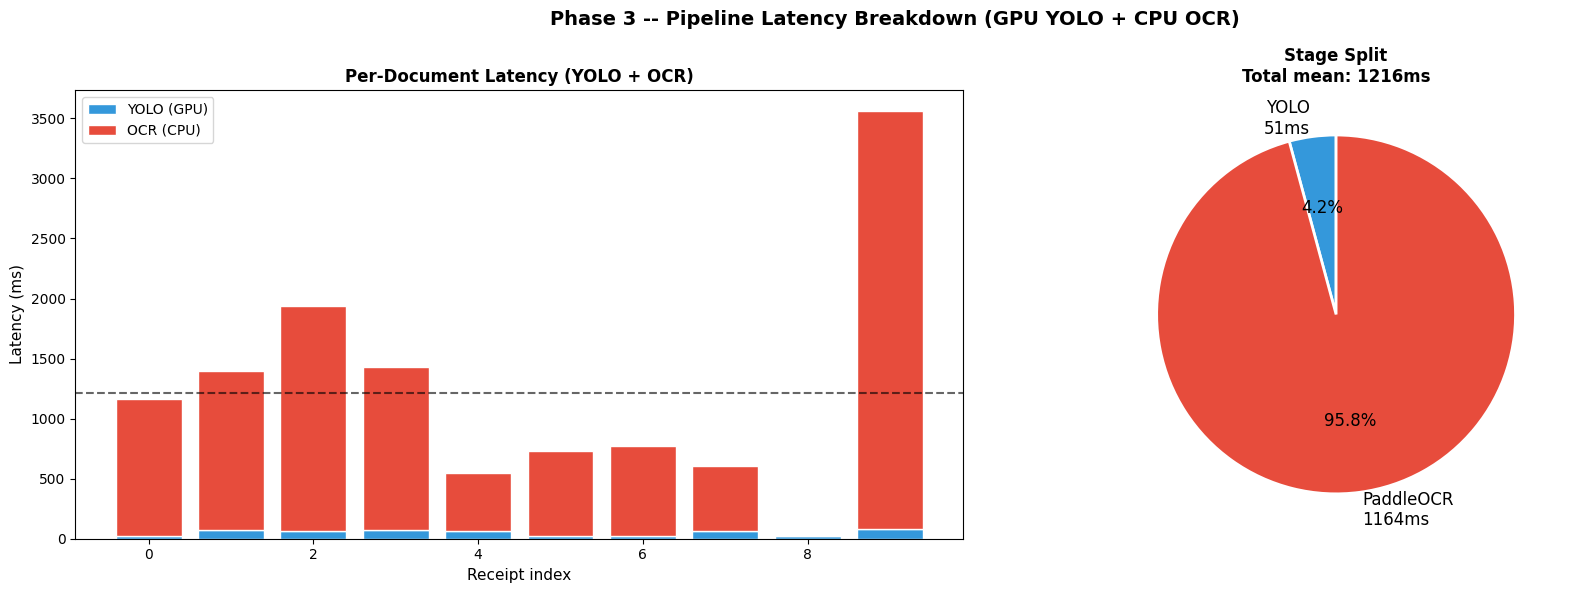

Saved -> /kaggle/working/doc-extraction-pipeline/outputs/annotated/phase3_latency.png


In [13]:
# Cell 13: Latency breakdown plot

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Phase 3 -- Pipeline Latency Breakdown (GPU YOLO + CPU OCR)',
             fontsize=14, fontweight='bold')

# Per-document stacked bar
x = range(N_BATCH)
axes[0].bar(x, yolo_times, label='YOLO (GPU)', color='#3498DB', edgecolor='white')
axes[0].bar(x, ocr_times,  label='OCR (CPU)',  color='#E74C3C', edgecolor='white',
            bottom=yolo_times)
axes[0].set_xlabel('Receipt index', fontsize=11)
axes[0].set_ylabel('Latency (ms)', fontsize=11)
axes[0].set_title('Per-Document Latency (YOLO + OCR)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].axhline(y=np.mean(total_times), color='black', linestyle='--',
                alpha=0.6, label=f'Mean {np.mean(total_times):.0f}ms')

# Stage comparison pie
stage_means = [np.mean(yolo_times), np.mean(ocr_times)]
stage_labels= [f'YOLO\n{np.mean(yolo_times):.0f}ms',
               f'PaddleOCR\n{np.mean(ocr_times):.0f}ms']
axes[1].pie(stage_means, labels=stage_labels,
            colors=['#3498DB','#E74C3C'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize':12},
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title(f'Stage Split\nTotal mean: {np.mean(total_times):.0f}ms',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
save_path = OUTPUTS_DIR / 'phase3_latency.png'
plt.savefig(save_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved -> {save_path}')

In [14]:
# Cell 14: Save all Phase 3 results

print('Saving Phase 3 results...')

# 1. Phase 3 results JSON
phase3_results = {
    'phase':  3,
    'title':  'Tesseract Integration',
    'ocr': {
        'engine':        'Tesseract',
        'lang':          'en',
        'use_angle_cls': True,
        'device':        'CPU',
    },
    'pipeline': {
        'stage_1': 'YOLO26 layout detection',
        'stage_2': 'PaddleOCR per region',
        'stage_3': 'Word bbox mapping to original coords',
    },
    'latency': {
        'yolo_ms_mean':  round(float(np.mean(yolo_times)),  1),
        'ocr_ms_mean':   round(float(np.mean(ocr_times)),   1),
        'total_ms_mean': round(float(np.mean(total_times)), 1),
        'device':        f'YOLO on {"GPU" if n_gpus>0 else "CPU"}, OCR on CPU',
        'note':          'LayoutLMv3 adds ~1-2s in Phase 4',
    },
    'per_doc': {
        'avg_regions': round(float(np.mean(regions_per_doc)), 1),
        'avg_words':   round(float(np.mean(words_per_doc)),   1),
    },
    'test_receipts': N_BATCH,
    'files': {
        'ocr_engine': str(SRC_DIR / 'ocr_engine.py'),
    },
}

results_path = RESULTS_DIR / 'phase3_results.json'
results_path.write_text(json.dumps(phase3_results, indent=2))
print(f'  phase3_results.json  ({results_path.stat().st_size} bytes)')

# 2. Phase 3 markdown summary
md = f'''# Phase 3 Results -- PaddleOCR Integration

## Pipeline
Stage 1: YOLO26 layout detection -> region bboxes
Stage 2: PaddleOCR on each cropped region -> word text + bboxes
Stage 3: Map word bboxes back to full-image coords

## Latency ({N_BATCH} SROIE receipts)
| Stage | Mean (ms) |
|-------|-----------|
| YOLO detection | {np.mean(yolo_times):.0f} |
| PaddleOCR (all regions) | {np.mean(ocr_times):.0f} |
| Total (Phases 2+3) | {np.mean(total_times):.0f} |
| LayoutLMv3 KIE (Phase 4 estimate) | 1000-2000 |
| **Full Path A target** | **< 5000** |

## Per Document
- Avg regions detected: {np.mean(regions_per_doc):.1f}
- Avg words extracted: {np.mean(words_per_doc):.1f}

## Next Step
Phase 4 -- LayoutLMv3 KIE fine-tuning on CORD (T4 x2 GPU)
Input: word tokens + xyxy bboxes from this stage
Output: field labels (vendor_name, date, total, etc.)
'''

(RESULTS_DIR / 'phase3_summary.md').write_text(md)
print(f'  phase3_summary.md saved')

# 3. Save one example pipeline JSON output for Phase 4 format reference
example_out = {
    'image': Path(test_paths[0]).name,
    'regions': pipeline_output,
}
# Convert numpy types to Python native
def make_serialisable(obj):
    if isinstance(obj, dict):
        return {k: make_serialisable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_serialisable(i) for i in obj]
    elif isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    return obj

(RESULTS_DIR / 'phase3_example_output.json').write_text(
    json.dumps(make_serialisable(example_out), indent=2)
)
print(f'  phase3_example_output.json saved')

print('\nAll Phase 3 files:')
for f in sorted(WORKING_DIR.rglob('*')):
    if f.is_file() and f.stat().st_size > 1024:
        print(f'  [{f.stat().st_size//1024:>6} KB]  {f.relative_to(WORKING_DIR)}')

Saving Phase 3 results...
  phase3_results.json  (691 bytes)
  phase3_summary.md saved
  phase3_example_output.json saved

All Phase 3 files:
  [    75 KB]  outputs/annotated/phase3_latency.png
  [   610 KB]  outputs/annotated/phase3_pipeline_single.png
  [     1 KB]  results/phase2_results.json
  [    28 KB]  results/phase3_example_output.json
  [     4 KB]  src/__pycache__/ocr_engine.cpython-312.pyc
  [     2 KB]  src/ocr_engine.py
  [     3 KB]  src/schema.py


---
## Phase 3 Summary

In [15]:
# Cell 16: Phase 3 summary dashboard

print('=' * 62)
print('PHASE 3 COMPLETE -- Tesseract Integration')
print('=' * 62)

print(f'''
  OCR Engine:   Tesseract (CPU, use_angle_cls=True)
  Test batch:   {N_BATCH} SROIE receipts

  Latency per document (GPU YOLO + CPU OCR):
    YOLO stage:     {np.mean(yolo_times):>6.0f} ms
    PaddleOCR:      {np.mean(ocr_times):>6.0f} ms
    Phases 2+3:     {np.mean(total_times):>6.0f} ms
    LayoutLMv3 est: ~1500 ms  (Phase 4)
    Full Path A:    ~{np.mean(total_times)+1500:.0f} ms  (target < 5000ms)

  Per document:
    Avg regions:    {np.mean(regions_per_doc):.1f}
    Avg words:      {np.mean(words_per_doc):.1f}
''')

print('  Key files saved:')
key_files = [
    SRC_DIR / 'ocr_engine.py',
    RESULTS_DIR / 'phase3_results.json',
    RESULTS_DIR / 'phase3_summary.md',
    RESULTS_DIR / 'phase3_example_output.json',
    OUTPUTS_DIR / 'phase3_pipeline_single.png',
    OUTPUTS_DIR / 'phase3_latency.png',
]
for f in key_files:
    status = 'OK' if f.exists() else 'MISSING'
    size   = f'{f.stat().st_size//1024} KB' if f.exists() else ''
    print(f'  [{status:<7}]  {str(f.relative_to(WORKING_DIR)):<50} {size}')

print(f'''
  NEXT STEP:
  1. Save output as Kaggle dataset: sdep-phase-3-output
  2. Phase 4 -- LayoutLMv3 KIE fine-tuning (T4 x2 GPU)
     Input:  word tokens + xyxy bboxes from ocr_engine.py
     Train:  CORD dataset (800 receipts, 30 field types)
     Output: field labels per token (vendor, date, total ...)
''')
print('=' * 62)

PHASE 3 COMPLETE -- Tesseract Integration

  OCR Engine:   Tesseract (CPU, use_angle_cls=True)
  Test batch:   10 SROIE receipts

  Latency per document (GPU YOLO + CPU OCR):
    YOLO stage:         51 ms
    PaddleOCR:        1164 ms
    Phases 2+3:       1216 ms
    LayoutLMv3 est: ~1500 ms  (Phase 4)
    Full Path A:    ~2716 ms  (target < 5000ms)

  Per document:
    Avg regions:    5.4
    Avg words:      80.5

  Key files saved:
  [OK     ]  src/ocr_engine.py                                  2 KB
  [OK     ]  results/phase3_results.json                        0 KB
  [OK     ]  results/phase3_summary.md                          0 KB
  [OK     ]  results/phase3_example_output.json                 28 KB
  [OK     ]  outputs/annotated/phase3_pipeline_single.png       610 KB
  [OK     ]  outputs/annotated/phase3_latency.png               75 KB

  NEXT STEP:
  1. Save output as Kaggle dataset: sdep-phase-3-output
  2. Phase 4 -- LayoutLMv3 KIE fine-tuning (T4 x2 GPU)
     Input:  word 